In [1]:
"""
# 05 — Data Augmentation para Imágenes

"Módulo:" 05 — Deep Learning para Clasificación  
"Framework:" TensorFlow / Keras  
"Dataset:" MNIST
---
## ¿Qué vamos a aprender en este notebook?
1. Qué es data augmentation y por qué es fundamental
2. Qué transformaciones son válidas y cuáles no para cada problema
3. Implementar augmentation con Keras layers
4. Comparar una CNN sin y con augmentation
5. Visualizar el efecto del augmentation sobre las imágenes
---
Data augmentation es una de las técnicas más simples y efectivas para mejorar la generalización de un modelo - especialmente cuando el dataset es pequeño.
## 1. ¿Qué es data augmentation?
Data augmentation es una técnica que "genera nuevas imágenes de entrenamiento"
aplicando transformaciones aleatorias a las imágenes existentes.
Imagen original      Versiones aumentadas
┌─────────────────────────────────┐
│  Rotada  │  Desplazada  │  Zoom  │
[  3  ]    →     │  [ 3 ]   │   [  3  ]    │ [ 3 ]  │
│  Espejo  │   Ruido      │  Brillo│
│  [ Ɛ ]   │   [ 3̃ ]      │ [  3 ] │
└─────────────────────────────────┘
### ¿Por qué funciona?
| Beneficio | Descripción |
|---|---|
| "Más datos" | El modelo ve más variaciones durante el entrenamiento |
| "Regularización" | Reduce el overfitting al evitar memorizar imágenes exactas |
| "Invarianza" | El modelo aprende que un objeto rotado sigue siendo el mismo objeto |
### Importante
El augmentation se aplica "solo durante el entrenamiento" — nunca sobre el conjunto de validación o test.
## 2. ¿Qué transformaciones son válidas?
No todas las transformaciones son apropiadas para todos los problemas.
Hay que pensar si la transformación "preserva la clase".
### Para MNIST — dígitos escritos a mano
| Transformación | ¿Válida? | Motivo |
|---|---|---|
| Rotación leve (±10°) | ✅ | Un 3 rotado levemente sigue siendo un 3 |
| Desplazamiento | ✅ | El dígito sigue siendo el mismo en otra posición |
| Zoom leve | ✅ | El dígito sigue siendo reconocible |
| Ruido gaussiano | ✅ | Simula variaciones en la escritura |
| Rotación extrema (180°) | ❌ | Un 6 rotado 180° parece un 9 |
| Espejo horizontal | ❌ | Un 3 espejado no es un dígito válido |
| Espejo vertical | ❌ | Cambia completamente la forma del dígito |
Esta es una decisión de "dominio" — hay que conocer el problema para elegir las transformaciones correctas. Una transformación válida para dígitos puede ser inválida para otro dataset.
"""

'\n# 05 — Data Augmentation para Imágenes\n\n"Módulo:" 05 — Deep Learning para Clasificación  \n"Framework:" TensorFlow / Keras  \n"Dataset:" MNIST\n---\n## ¿Qué vamos a aprender en este notebook?\n1. Qué es data augmentation y por qué es fundamental\n2. Qué transformaciones son válidas y cuáles no para cada problema\n3. Implementar augmentation con Keras layers\n4. Comparar una CNN sin y con augmentation\n5. Visualizar el efecto del augmentation sobre las imágenes\n---\nData augmentation es una de las técnicas más simples y efectivas para mejorar la generalización de un modelo - especialmente cuando el dataset es pequeño.\n## 1. ¿Qué es data augmentation?\nData augmentation es una técnica que "genera nuevas imágenes de entrenamiento"\naplicando transformaciones aleatorias a las imágenes existentes.\nImagen original      Versiones aumentadas\n┌─────────────────────────────────┐\n│  Rotada  │  Desplazada  │  Zoom  │\n[  3  ]    →     │  [ 3 ]   │   [  3  ]    │ [ 3 ]  │\n│  Espejo  │   

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [3]:
# Cargar MNIST
(X_train_raw, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar
X_train_raw = X_train_raw.astype('float32') / 255.0
X_test      = X_test.astype('float32')      / 255.0

# Agregar canal
X_train_raw = X_train_raw[..., np.newaxis]
X_test      = X_test[..., np.newaxis]

# Separar validación
X_val   = X_train_raw[50000:]
X_train = X_train_raw[:50000]
y_val   = y_train[50000:]
y_train = y_train[:50000]

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 50000 muestras
Val:   10000 muestras
Test:  10000 muestras


In [4]:
"""
## 3. Implementar data augmentation con Keras
En Keras 3 el augmentation se implementa como "capas del modelo".
Esto tiene tres ventajas importantes:
| Ventaja | Descripción |
|---|---|
| "Integrado al modelo" | No hay código separado de preprocesamiento |
| "Ejecuta en GPU" | Las transformaciones se aplican en GPU si está disponible |
| "Solo en entrenamiento" | Keras desactiva estas capas automáticamente en inferencia |
### Las capas de augmentation que vamos a usar
python
keras.layers.RandomRotation(factor=0.1)      # Rotación ±10%
keras.layers.RandomTranslation(0.1, 0.1)     # Desplazamiento ±10%
keras.layers.RandomZoom(0.1)                 # Zoom ±10%
keras.layers.GaussianNoise(stddev=0.05)      # Ruido gaussiano
"""

'\n## 3. Implementar data augmentation con Keras\nEn Keras 3 el augmentation se implementa como "capas del modelo".\nEsto tiene tres ventajas importantes:\n| Ventaja | Descripción |\n|---|---|\n| "Integrado al modelo" | No hay código separado de preprocesamiento |\n| "Ejecuta en GPU" | Las transformaciones se aplican en GPU si está disponible |\n| "Solo en entrenamiento" | Keras desactiva estas capas automáticamente en inferencia |\n### Las capas de augmentation que vamos a usar\npython\nkeras.layers.RandomRotation(factor=0.1)      # Rotación ±10%\nkeras.layers.RandomTranslation(0.1, 0.1)     # Desplazamiento ±10%\nkeras.layers.RandomZoom(0.1)                 # Zoom ±10%\nkeras.layers.GaussianNoise(stddev=0.05)      # Ruido gaussiano\n'

In [5]:
# Pipeline de augmentation como modelo secuencial
data_augmentation = keras.Sequential([
    layers.RandomRotation(factor=0.1),          # Rotación ±10%
    layers.RandomTranslation(0.1, 0.1),         # Desplazamiento ±10%
    layers.RandomZoom(0.1),                     # Zoom ±10%
    layers.GaussianNoise(stddev=0.05),          # Ruido gaussiano
], name='data_augmentation')

# Verificar que funciona pasando una imagen de prueba
test_img = X_train[:1]
augmented = data_augmentation(test_img, training=True)

print(f"Input shape:     {test_img.shape}")
print(f"Augmented shape: {augmented.shape}")
print("Pipeline de augmentation definido correctamente")

Input shape:     (1, 28, 28, 1)
Augmented shape: (1, 28, 28, 1)
Pipeline de augmentation definido correctamente


In [6]:
"""
## 4. Visualizar el efecto del augmentation
Antes de entrenar vamos a visualizar cómo el pipeline de augmentation
transforma las imágenes. Esto es importante para verificar que:
- Las transformaciones son razonables y no distorsionan demasiado
- Las imágenes aumentadas siguen siendo reconocibles
- El augmentation introduce suficiente variabilidad
Siempre visualizá el augmentation antes de entrenar — transformaciones demasiado agresivas pueden perjudicar el modelo en vez de ayudarlo.
"""

'\n## 4. Visualizar el efecto del augmentation\nAntes de entrenar vamos a visualizar cómo el pipeline de augmentation\ntransforma las imágenes. Esto es importante para verificar que:\n- Las transformaciones son razonables y no distorsionan demasiado\n- Las imágenes aumentadas siguen siendo reconocibles\n- El augmentation introduce suficiente variabilidad\nSiempre visualizá el augmentation antes de entrenar — transformaciones demasiado agresivas pueden perjudicar el modelo en vez de ayudarlo.\n'

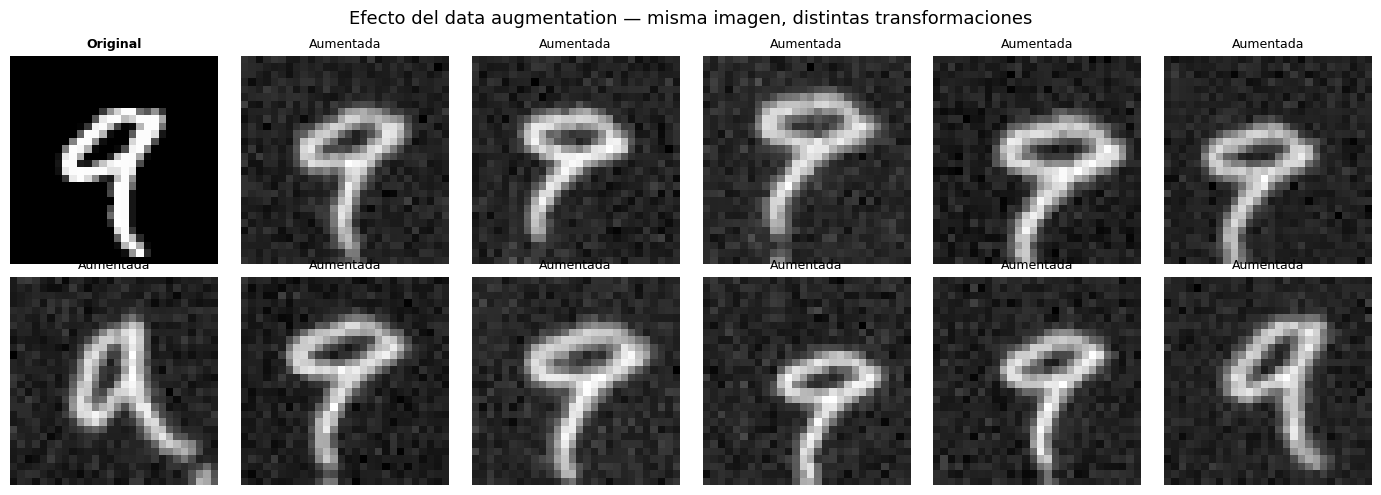

In [7]:
# Elegir un dígito para visualizar
digit_idx = np.where(y_train == 9)[0][0]
img = X_train[digit_idx:digit_idx+1]

# Generar 10 versiones aumentadas de la misma imagen
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Efecto del data augmentation — misma imagen, distintas transformaciones', fontsize=13)

# Imagen original
axes[0, 0].imshow(img[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original', fontsize=9, fontweight='bold')
axes[0, 0].axis('off')

# 11 versiones aumentadas
all_axes = list(axes.flatten())[1:]
for ax in all_axes:
    augmented = data_augmentation(img, training=True)
    ax.imshow(augmented[0, :, :, 0], cmap='gray')
    ax.set_title('Aumentada', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/05_augmentation_visualizacion.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
"""
## 5. Comparación — CNN sin vs con augmentation
Para ver el efecto real del augmentation vamos a entrenar dos modelos idénticos en arquitectura pero distintos en entrenamiento:
Modelo A (baseline)
Input → Conv → Pool → Conv → Pool → Flatten → Dense → Output
↑
Sin augmentation
Modelo B (con augmentation)
Input → Augmentation → Conv → Pool → Conv → Pool → Flatten → Dense → Output
↑
Augmentation integrado como capas
Para hacer la comparación más interesante vamos a usar un "subconjunto pequeño del train (5,000 muestras)" — con pocos datos el overfitting es más severo y el efecto del augmentation es más visible y fácil de analizar.
"""

'\n## 5. Comparación — CNN sin vs con augmentation\nPara ver el efecto real del augmentation vamos a entrenar dos modelos idénticos en arquitectura pero distintos en entrenamiento:\nModelo A (baseline)\nInput → Conv → Pool → Conv → Pool → Flatten → Dense → Output\n↑\nSin augmentation\nModelo B (con augmentation)\nInput → Augmentation → Conv → Pool → Conv → Pool → Flatten → Dense → Output\n↑\nAugmentation integrado como capas\nPara hacer la comparación más interesante vamos a usar un "subconjunto pequeño del train (5,000 muestras)" — con pocos datos el overfitting es más severo y el efecto del augmentation es más visible y fácil de analizar.\n'

In [9]:
# Subconjunto pequeño para hacer más visible el efecto
N_TRAIN = 5000
X_train_small = X_train[:N_TRAIN]
y_train_small = y_train[:N_TRAIN]

print(f"Train reducido: {X_train_small.shape[0]} muestras")

def build_model_baseline(input_shape=(28, 28, 1), num_classes=10):
    """CNN sin augmentation."""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='baseline')
    return model

def build_model_augmented(input_shape=(28, 28, 1), num_classes=10):
    """CNN con augmentation integrado."""
    model = keras.Sequential([
        # Augmentation como primeras capas
        layers.RandomRotation(factor=0.1),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomZoom(0.1),
        layers.GaussianNoise(stddev=0.05),
        # Arquitectura idéntica al baseline
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='augmented')
    return model

model_baseline  = build_model_baseline()
model_augmented = build_model_augmented()

print("Modelo baseline:  ", model_baseline.name)
print("Modelo augmented: ", model_augmented.name)

Train reducido: 5000 muestras
Modelo baseline:   baseline
Modelo augmented:  augmented


C:\Users\Peter\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Compilar ambos modelos
for model in [model_baseline, model_augmented]:
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

# Entrenar baseline
print("Entrenando modelo baseline (sin augmentation)...")
history_baseline = model_baseline.fit(
    X_train_small, y_train_small,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)
print("Baseline entrenado ✓")

# Entrenar con augmentation
print("Entrenando modelo con augmentation...")
history_augmented = model_augmented.fit(
    X_train_small, y_train_small,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)
print("Augmented entrenado ✓")

Entrenando modelo baseline (sin augmentation)...
Baseline entrenado ✓
Entrenando modelo con augmentation...
Augmented entrenado ✓


In [13]:
"""
## 6. Comparar curvas de entrenamiento
Las curvas de loss y accuracy nos van a mostrar claramente
el efecto del augmentation:
- "Baseline": esperamos ver overfitting — train accuracy muy alta, val accuracy más baja y divergiendo
- "Augmented": esperamos ver menos overfitting — la brecha entre train y val debería ser menor
Con solo 5,000 muestras de entrenamiento el overfitting es casi inevitable sin técnicas de regularización como augmentation.
"""

'\n## 6. Comparar curvas de entrenamiento\nLas curvas de loss y accuracy nos van a mostrar claramente\nel efecto del augmentation:\n- "Baseline": esperamos ver overfitting — train accuracy muy alta, val accuracy más baja y divergiendo\n- "Augmented": esperamos ver menos overfitting — la brecha entre train y val debería ser menor\nCon solo 5,000 muestras de entrenamiento el overfitting es casi inevitable sin técnicas de regularización como augmentation.\n'

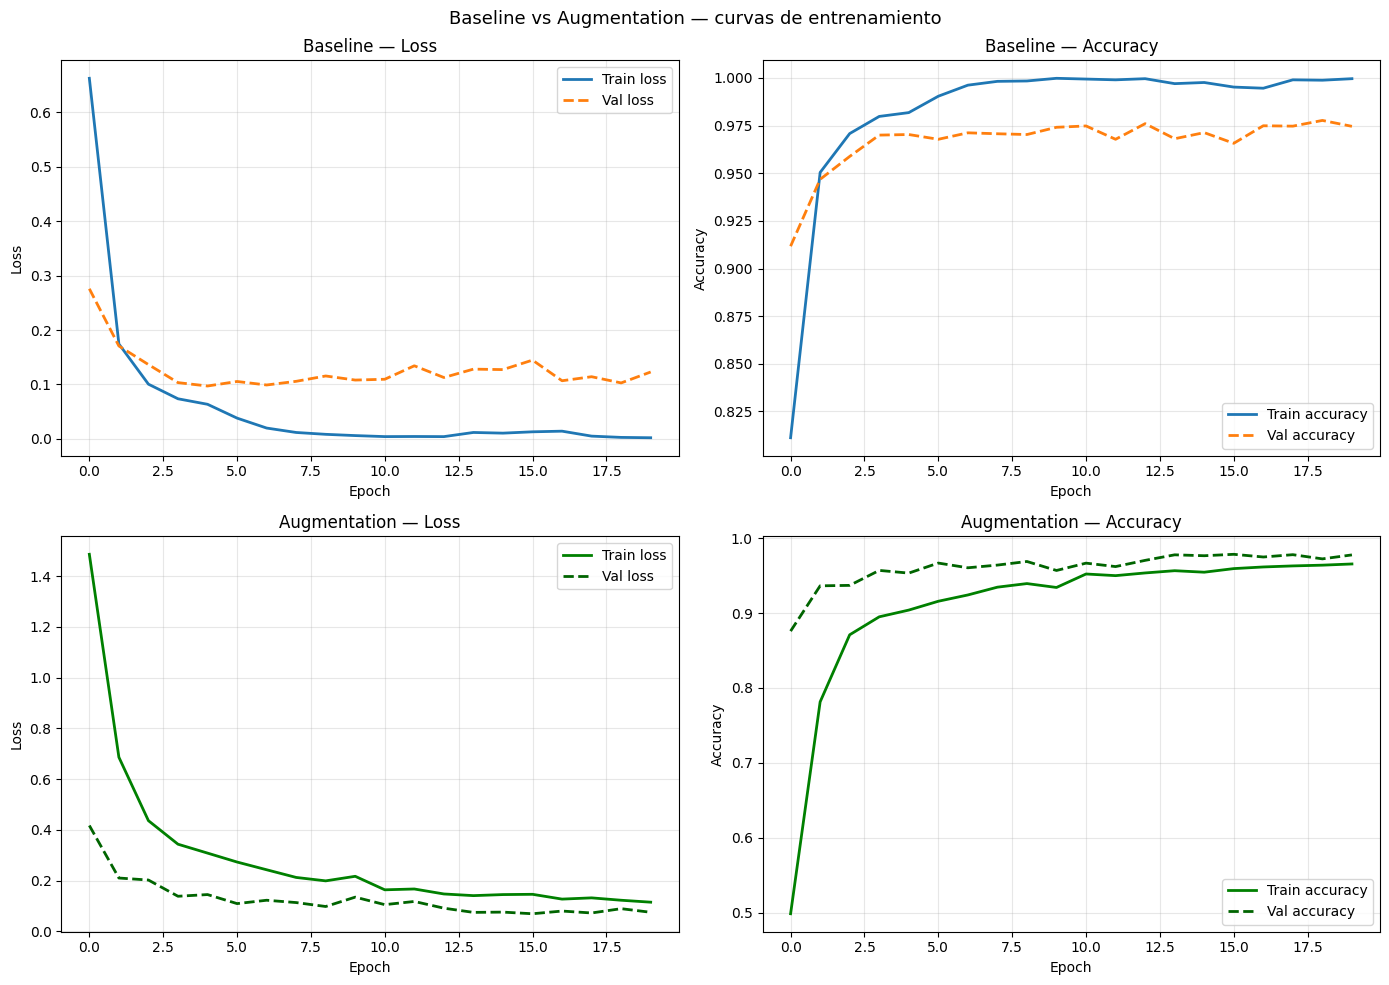

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Baseline vs Augmentation — curvas de entrenamiento', fontsize=13)

# --- Baseline Loss ---
axes[0, 0].plot(history_baseline.history['loss'],
                label='Train loss', linewidth=2)
axes[0, 0].plot(history_baseline.history['val_loss'],
                label='Val loss', linewidth=2, linestyle='--')
axes[0, 0].set_title('Baseline — Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# --- Baseline Accuracy ---
axes[0, 1].plot(history_baseline.history['accuracy'],
                label='Train accuracy', linewidth=2)
axes[0, 1].plot(history_baseline.history['val_accuracy'],
                label='Val accuracy', linewidth=2, linestyle='--')
axes[0, 1].set_title('Baseline — Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# --- Augmented Loss ---
axes[1, 0].plot(history_augmented.history['loss'],
                label='Train loss', linewidth=2, color='green')
axes[1, 0].plot(history_augmented.history['val_loss'],
                label='Val loss', linewidth=2, linestyle='--', color='darkgreen')
axes[1, 0].set_title('Augmentation — Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# --- Augmented Accuracy ---
axes[1, 1].plot(history_augmented.history['accuracy'],
                label='Train accuracy', linewidth=2, color='green')
axes[1, 1].plot(history_augmented.history['val_accuracy'],
                label='Val accuracy', linewidth=2, linestyle='--', color='darkgreen')
axes[1, 1].set_title('Augmentation — Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/05_curvas_comparacion.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
"""
## 7. Evaluación final en test set
Las curvas de entrenamiento nos dan una idea visual del efecto del augmentation. Ahora vamos a cuantificarlo evaluando ambos modelos sobre el test set.
Recordá que ambos modelos fueron entrenados con solo 5,000 muestras — muy por debajo de las 50,000 que usamos en el notebook 02. La diferencia de accuracy va a reflejar tanto el efecto del augmentation como la limitación del dataset pequeño.
"""

'\n## 7. Evaluación final en test set\nLas curvas de entrenamiento nos dan una idea visual del efecto del augmentation. Ahora vamos a cuantificarlo evaluando ambos modelos sobre el test set.\nRecordá que ambos modelos fueron entrenados con solo 5,000 muestras — muy por debajo de las 50,000 que usamos en el notebook 02. La diferencia de accuracy va a reflejar tanto el efecto del augmentation como la limitación del dataset pequeño.\n'

Modelo                      Test Accuracy       Test Loss
Baseline (sin aug)                  97.4%          0.1072
Con augmentation                    97.5%          0.0816

Mejora con augmentation: +0.1%


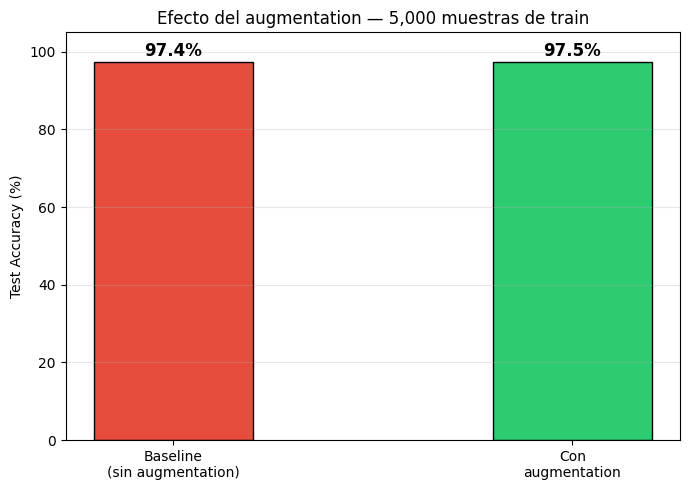

In [15]:
# Evaluar ambos modelos en test set
loss_baseline,  acc_baseline  = model_baseline.evaluate(X_test,  y_test, verbose=0)
loss_augmented, acc_augmented = model_augmented.evaluate(X_test, y_test, verbose=0)

# Tabla comparativa
print("="*60)
print(f"{'Modelo':<25} {'Test Accuracy':>15} {'Test Loss':>15}")
print("="*60)
print(f"{'Baseline (sin aug)':<25} {acc_baseline*100:>14.1f}% {loss_baseline:>15.4f}")
print(f"{'Con augmentation':<25} {acc_augmented*100:>14.1f}% {loss_augmented:>15.4f}")
print("="*60)
print(f"\nMejora con augmentation: +{(acc_augmented - acc_baseline)*100:.1f}%")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(7, 5))

modelos  = ['Baseline\n(sin augmentation)', 'Con\naugmentation']
accuracy = [acc_baseline * 100, acc_augmented * 100]
colores  = ['#e74c3c', '#2ecc71']

bars = ax.bar(modelos, accuracy, color=colores, width=0.4, edgecolor='black')
ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title(f'Efecto del augmentation — 5,000 muestras de train', fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/05_comparacion_final.png', dpi=120, bbox_inches='tight')
plt.show()